# Assignment 1: Building Neural Networks for Image Classification

## Overview
Welcome back to Assignment 1! In this assignment, you'll dive into the fascinating realm of deep learning by building and training neural networks for image classification and object detection tasks using the PyTorch framework. You'll work with two popular datasets: MNIST for image classification and CIFAR-100 for object detection. Throughout the assignment, you'll also fine-tune your models to achieve optimal results.

## Part 3: Achieve Best Accuracy
In the final section of the assignment, you'll take your models to the next level by modifying the model and achieving benchmark performance. You'll experiment with different architectures, hyperparameters, learning rates, and optimization techniques to achieve the best possible accuracy for object classification (CIFAR-100). Your journey will involve analyzing the impact of these changes on the models' accuracy and convergence. Feel free to write your own modules, and make changes to starter code to achieve highest possible accuracy. Results are expected to be submitted in the same format as previous sections however.

Note: You can implement one of the AlexNet, ResNet18, ResNet50, or other architectures discussed in class. However, No transfer learning or pretrained models allowed.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f" {torch.cuda.get_device_name(0)}")
# Specify font family to avoid font warnings on Colab
plt.rcParams['font.family'] = 'DejaVu Sans'

 NVIDIA GeForce RTX 2050


In [3]:
from data import get_dataloaders
import neural_network
import trainer
import visualize

In [4]:
# Hyperparameters
# TODO: Experiment with different hyperparameters
batch_size = 32
learning_rate = 0.001
epochs = 20

In [5]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
 # TODO: note that you want to keep
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
  # TODO

trainloader, testloader = get_dataloaders(
    dataset_name="cifar100", 
    batch_size=batch_size, 
    train_transforms=transform_train, 
    test_transforms=transform_test
)

Files already downloaded and verified
Files already downloaded and verified


In [6]:
# TODO: Initialize the model, loss function, and optimizer
model = neural_network.BetterModel(num_classes=100, in_channels=3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

#optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

In [7]:
# TODO: Training loop
train_losses, test_losses = trainer.train(
    model, optimizer, criterion, trainloader, testloader, epochs, device
)

Epoch 1/20 - Train Loss: 3.8817078691984093
Epoch 1/20 - Test Loss: 3.4333798413078624
Epoch 1/20 - Test Accuracy: 17.21%
Epoch 2/20 - Train Loss: 3.1492716921344446
Epoch 2/20 - Test Loss: 2.899826708693093
Epoch 2/20 - Test Accuracy: 27.85%
Epoch 3/20 - Train Loss: 2.605108157610634
Epoch 3/20 - Test Loss: 2.3120748928179755
Epoch 3/20 - Test Accuracy: 38.33%
Epoch 4/20 - Train Loss: 2.222772862388015
Epoch 4/20 - Test Loss: 2.060094184768847
Epoch 4/20 - Test Accuracy: 44.62%
Epoch 5/20 - Train Loss: 1.9426359903026833
Epoch 5/20 - Test Loss: 1.8698475977864129
Epoch 5/20 - Test Accuracy: 49.52%
Epoch 6/20 - Train Loss: 1.7363605633501966
Epoch 6/20 - Test Loss: 1.7792338597507904
Epoch 6/20 - Test Accuracy: 52.13%
Epoch 7/20 - Train Loss: 1.5600032943300306
Epoch 7/20 - Test Loss: 1.5705298533835732
Epoch 7/20 - Test Accuracy: 56.42%
Epoch 8/20 - Train Loss: 1.415199253853513
Epoch 8/20 - Test Loss: 1.5477844943253758
Epoch 8/20 - Test Accuracy: 57.82%
Epoch 9/20 - Train Loss: 1.29

# Visualize Final Results: Best Model - CIFAR 100

In [8]:
# Evaluate the models
accuracy = trainer.evaluate_accuracy(model, testloader, device)

# Print test accuracy
print("Best Model Test Accuracy:", accuracy)

Best Model Test Accuracy: 66.61


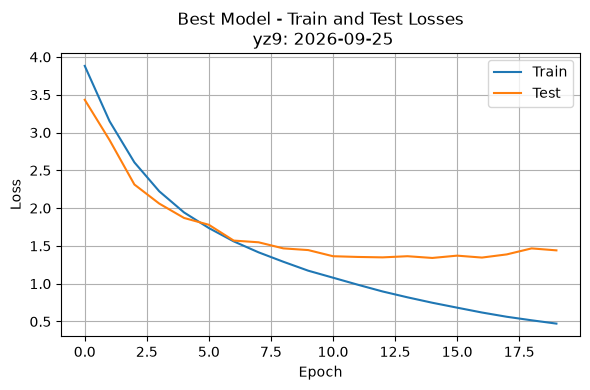

In [9]:
# Plot train and test losses
visualize.visualize_loss(train_losses, test_losses, "Best Model")

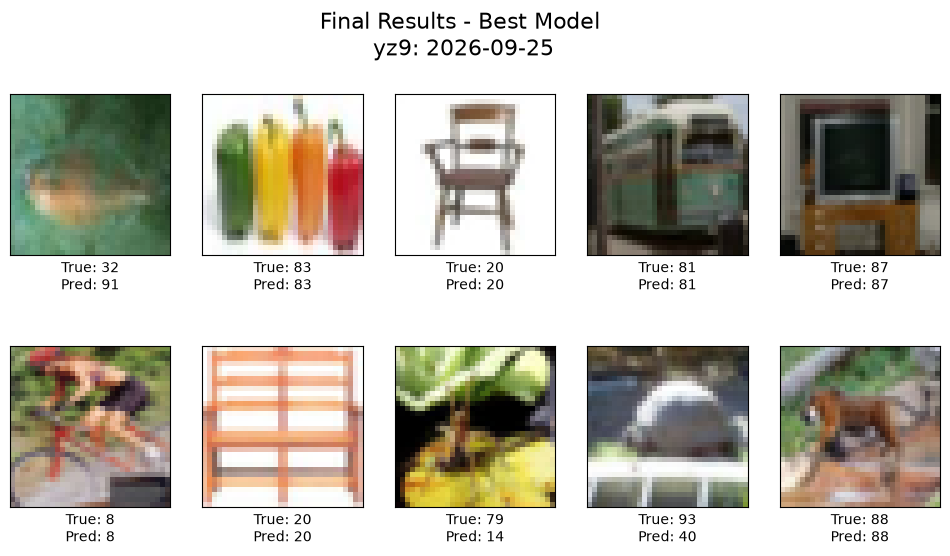

In [10]:
# Visualize the final results
visualize.visualize_images(model, testloader.dataset, device, "Best Model")